In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import pandas as pd

drive_path = '/content/drive/Shareddrives/DATA_GPI/Grupo2_Desarrollo/Hito4/Actividad2/dataset_features_biovid_normalizado_V2_Final.csv'
local_path = '/content/dataset_features_biovid_normalizado_V2_Final.csv'

# Función para cargar el archivo CSV
def cargar_archivo(ruta):
    return pd.read_csv(ruta)

# Proceso de búsqueda y carga
if os.path.exists(drive_path):
    print("¡Archivo encontrado en Google Drive! Cargando...")
    df_data = cargar_archivo(drive_path)
    print("¡Datos cargados con éxito desde Drive!")

elif os.path.exists(local_path):
    print("No se encontró en Drive, pero sí en la copia local. Cargando...")
    df_data = cargar_archivo(local_path)
    print("¡Datos cargados con éxito desde la copia local!")

else:
    print("❌ ERROR: El archivo no existe en ninguna de las rutas especificadas.")

# Mostrar las primeras filas para confirmar que todo está bien
if 'df_data' in locals():
    print(df_data.head(2))

¡Archivo encontrado en Google Drive! Cargando...
¡Datos cargados con éxito desde Drive!
   subject_id subject_name  class_id class_name  sample_id  \
0           1  071309_w_21         0        BL1          1   
1           1  071309_w_21         0        BL1          2   

           sample_name   ecg_bpm  ecg_rmssd  ecg_rr_range   ecg_lzc  ...  \
0  071309_w_21-BL1-081 -0.775515  -0.524538     -0.789997 -0.213687  ...   
1  071309_w_21-BL1-082 -0.775515  -0.358860     -0.203075 -0.213687  ...   

   emg_corrugator_zcr  emg_corrugator_lzc  emg_corrugator_apen  \
0           -1.295212            0.268009             2.030110   
1           -1.285107            0.064972             2.242401   

   emg_zygomaticus_max  emg_zygomaticus_mean  emg_zygomaticus_std  \
0             1.874731              4.250872             2.940389   
1             0.949672              1.822393             1.121267   

   emg_zygomaticus_auc  emg_zygomaticus_zcr  emg_zygomaticus_lzc  \
0             4.25120

=== VERIFICACIÓN DE BALANCE DE CLASES ===
class_name
BL1    1720
PA1    1720
PA2    1720
PA3    1720
PA4    1720
Name: count, dtype: int64


/tmp/ipykernel_3916/416754798.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='class_name', data=df_data, palette='viridis')


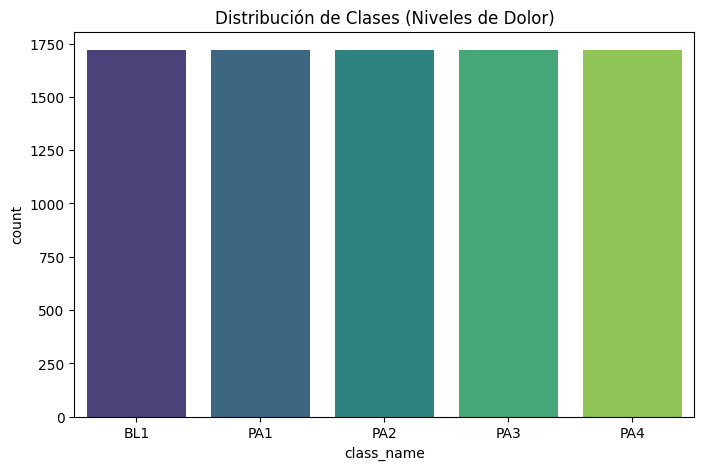


=== ESTADÍSTICAS DESCRIPTIVAS ===


,mean,std,min,max
ecg_bpm,1.186047e-08,1.000058,-7.708408,4.644198
gsr_max_amplitude,-7.790698e-09,1.000058,-8.279128,6.245914
emg_trapezius_mean,-6.279070e-09,1.000058,-2.188844,9.949874
emg_corrugator_mean,4.883721e-09,1.000058,-2.776164,9.244215
emg_zygomaticus_mean,-2.209302e-09,1.000058,-1.683933,9.543774


/tmp/ipykernel_3916/416754798.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Estado de Dolor', y=col, data=df_comparativa, palette='Set2')
/tmp/ipykernel_3916/416754798.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Estado de Dolor', y=col, data=df_comparativa, palette='Set2')
/tmp/ipykernel_3916/416754798.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Estado de Dolor', y=col, data=df_comparativa, palette='Set2')
/tmp/ipykernel_3916/416754798.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is depr

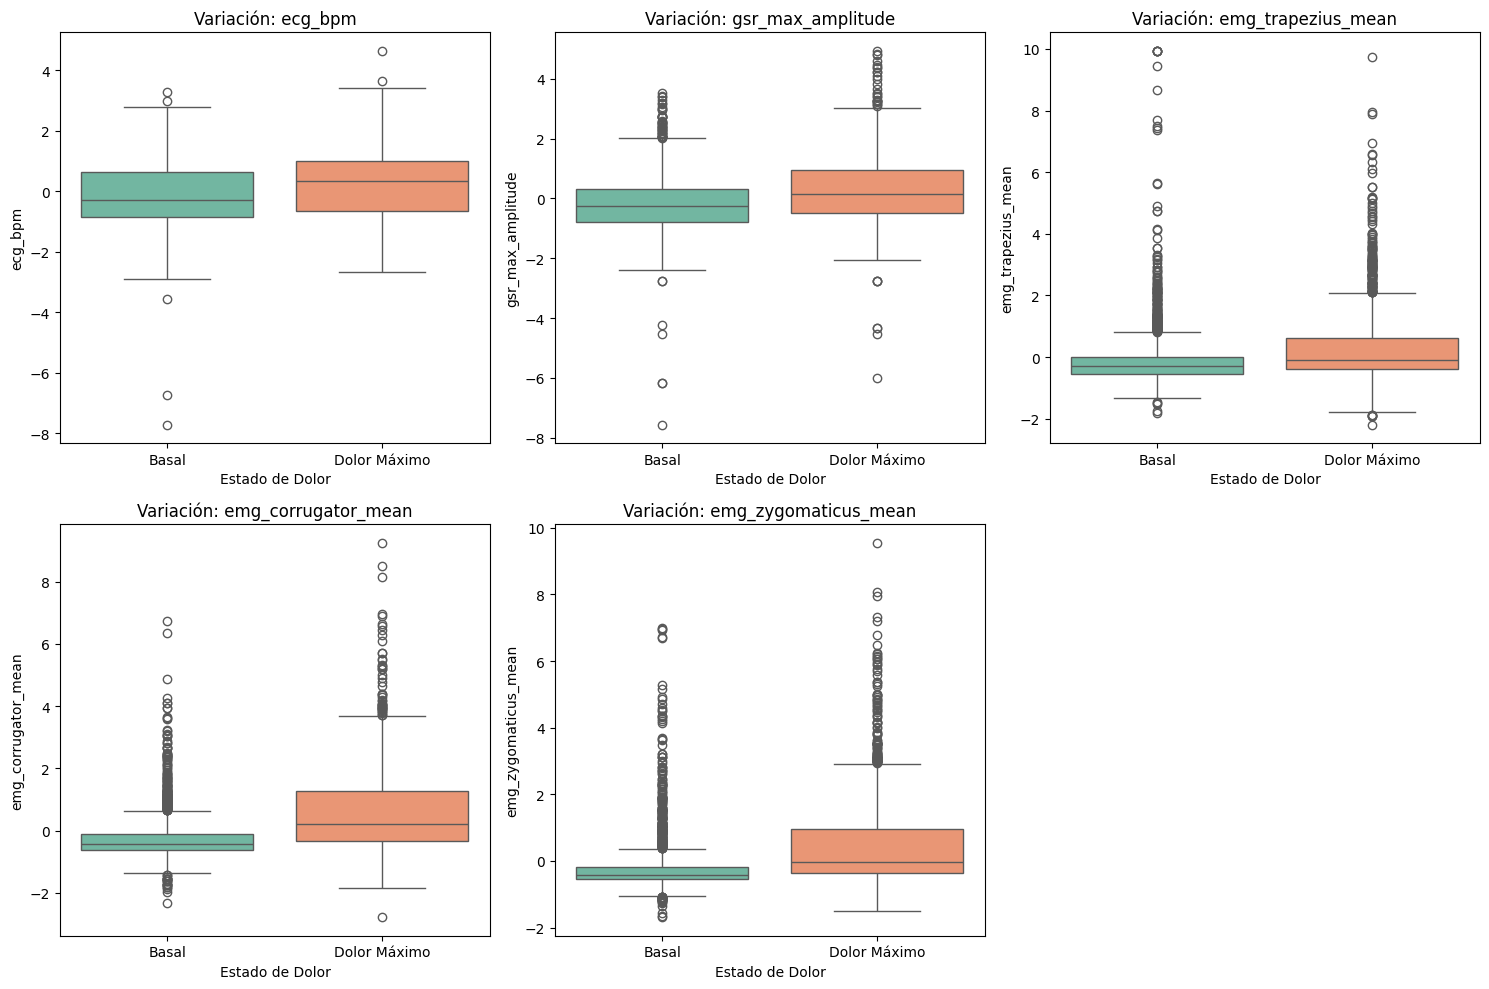

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- EDA: DISTRIBUCIÓN Y ESTADÍSTICAS ---

if 'df_data' in locals():

    print("=== VERIFICACIÓN DE BALANCE DE CLASES ===")

    if 'class_name' in df_data.columns:

        print(df_data['class_name'].value_counts().sort_index())

        plt.figure(figsize=(8, 5))

        sns.countplot(x='class_name', data=df_data, palette='viridis')

        plt.title('Distribución de Clases (Niveles de Dolor)')

        plt.show()

    columnas_fisiologicas = [

        'ecg_bpm', 'gsr_max_amplitude',

        'emg_trapezius_mean', 'emg_corrugator_mean',

        'emg_zygomaticus_mean'

    ]

    cols_presentes = [c for c in columnas_fisiologicas if c in df_data.columns]

    print("\n=== ESTADÍSTICAS DESCRIPTIVAS ===")

    display(df_data[cols_presentes].describe().T[['mean', 'std', 'min', 'max']])

    # Boxplots Basal vs Dolor Máximo

    if 'class_id' in df_data.columns:

        df_comparativa = df_data[df_data['class_id'].isin([0, 4])].copy()

        df_comparativa['Estado de Dolor'] = df_comparativa['class_id'].map({0: 'Basal', 4: 'Dolor Máximo'})

        plt.figure(figsize=(15, 10))

        for i, col in enumerate(cols_presentes, 1):

            plt.subplot(2, 3, i)

            sns.boxplot(x='Estado de Dolor', y=col, data=df_comparativa, palette='Set2')

            plt.title(f'Variación: {col}')

        plt.tight_layout()

        plt.show()

=== INICIANDO ANÁLISIS DE INFORMACIÓN MUTUA ===
✓ Columnas no numéricas excluidas automáticamente.
✓ Dimensiones de X a analizar: (8600, 32) (32 características numéricas)
Ejecutando mutual_info_classif 10 veces con diferentes random_states...


/tmp/ipykernel_3916/2285105788.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


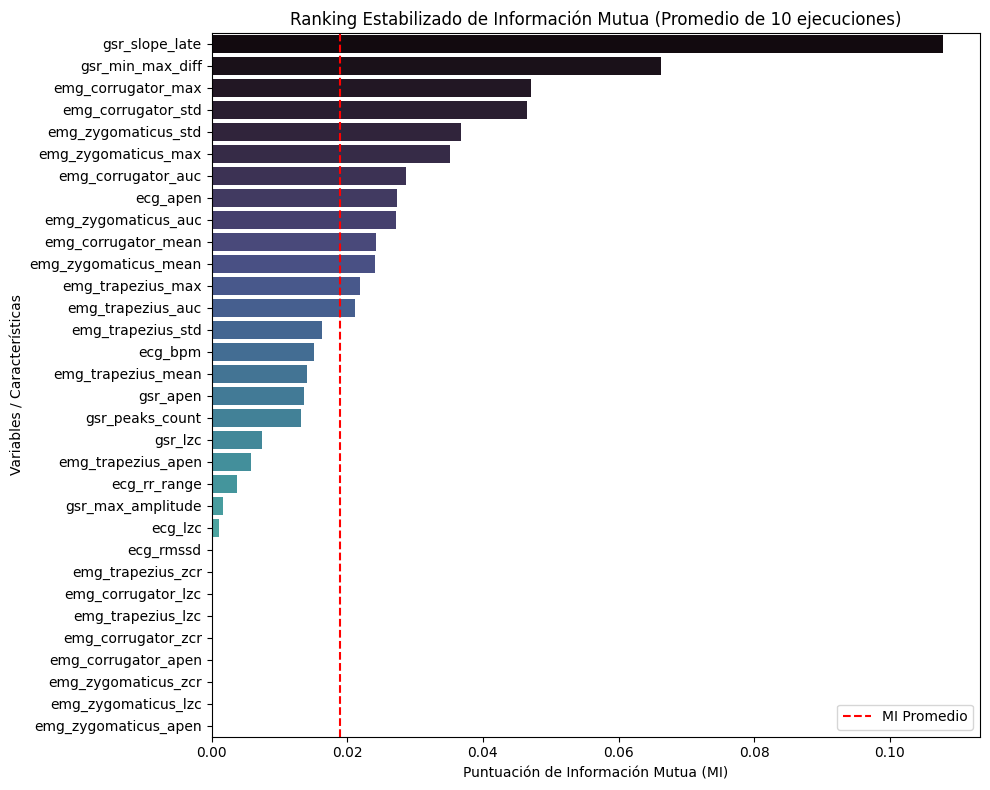


=== RANKING DE VARIABLES (ORDENADO DE MAYOR A MENOR MI) ===


,Característica,Información_Mutua
0,gsr_slope_late,0.107900
1,gsr_min_max_diff,0.066261
2,emg_corrugator_max,0.047059
3,emg_corrugator_std,0.046457
4,emg_zygomaticus_std,0.036812
5,emg_zygomaticus_max,0.035114
6,emg_corrugator_auc,0.028696
7,ecg_apen,0.027336
8,emg_zygomaticus_auc,0.027135
9,emg_corrugator_mean,0.024260


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif

# --- TAREA 2: ANÁLISIS PROFUNDO Y AJUSTE DEL RANKING DE INFORMACIÓN MUTUA (MI) ---

if 'df_data' in locals():
    print("=== INICIANDO ANÁLISIS DE INFORMACIÓN MUTUA ===")

    # 1. Definir la variable objetivo (Target)
    target_col = 'class_id' if 'class_id' in df_data.columns else 'class_name'
    y = df_data[target_col]

    # 2. SELECCIÓN AUTOMÁTICA DE CARACTERÍSTICAS NUMÉRICAS (Solución al Error)
    # Filtramos para quedarnos ÚNICAMENTE con columnas flotantes o enteras
    X_numeric = df_data.select_dtypes(include=[np.number])

    # Excluimos variables objetivo del set de características si es que son numéricas
    columnas_a_remover = [target_col, 'class_id', 'subject_id', 'sample_id']
    columnas_features = [c for c in X_numeric.columns if c not in columnas_a_remover]

    X = X_numeric[columnas_features]

    print(f"✓ Columnas no numéricas excluidas automáticamente.")
    print(f"✓ Dimensiones de X a analizar: {X.shape} ({X.shape[1]} características numéricas)")

    # 3. Control del componente estocástico (Múltiples ejecuciones)
    n_runs = 10
    mi_scores_acumulados = np.zeros(X.shape[1])

    print(f"Ejecutando mutual_info_classif {n_runs} veces con diferentes random_states...")
    for seed in range(n_runs):
        # Usamos 'seed' en lugar de un número fijo para que realmente varíe el estado estocástico
        mi_scores = mutual_info_classif(X, y, random_state=seed)
        mi_scores_acumulados += mi_scores

    # Calcular el promedio de las puntuaciones de MI
    mi_scores_promedio = mi_scores_acumulados / n_runs

    # Crear un DataFrame con el Ranking
    df_ranking = pd.DataFrame({
        'Característica': columnas_features,
        'Información_Mutua': mi_scores_promedio
    }).sort_values(by='Información_Mutua', ascending=False).reset_index(drop=True)

    # 4. Graficar el Ranking Completo de Variables (Barras Horizontales)
    plt.figure(figsize=(10, 8))
    sns.barplot(
        x='Información_Mutua',
        y='Característica',
        data=df_ranking,
        palette='mako'
    )

    # Dibujar línea vertical en el promedio
    plt.axvline(x=df_ranking['Información_Mutua'].mean(), color='red', linestyle='--', label='MI Promedio')

    plt.title('Ranking Estabilizado de Información Mutua (Promedio de 10 ejecuciones)')
    plt.xlabel('Puntuación de Información Mutua (MI)')
    plt.ylabel('Variables / Características')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Mostrar el top de variables en texto
    print("\n=== RANKING DE VARIABLES (ORDENADO DE MAYOR A MENOR MI) ===")
    display(df_ranking)

else:
    print("❌ Error: 'df_data' no está disponible. Asegúrate de haber ejecutado las celdas de carga previas.")

Tarea 3: Optimización del Filtro de Multicolinealidad y Umbrales de Correlación

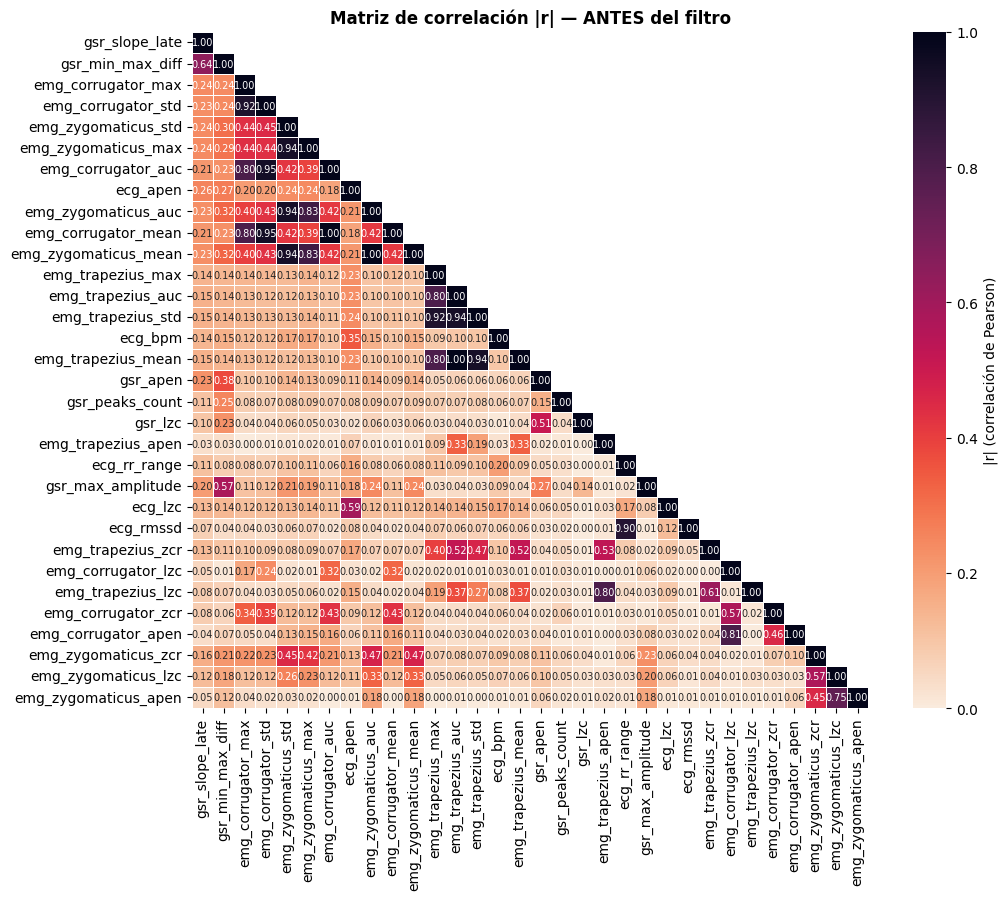

Umbral | Pares redundantes | Eliminadas | Sobreviven
----------------------------------------------------
  0.75  |         21        |     12     |     20
         -> eliminadas: ['ecg_rmssd', 'emg_corrugator_auc', 'emg_corrugator_lzc', 'emg_corrugator_max', 'emg_corrugator_std', 'emg_trapezius_auc', 'emg_trapezius_lzc', 'emg_trapezius_mean', 'emg_trapezius_std', 'emg_zygomaticus_max', 'emg_zygomaticus_mean', 'emg_zygomaticus_std']
  0.85  |         13        |      8     |     24
         -> eliminadas: ['ecg_rmssd', 'emg_corrugator_auc', 'emg_corrugator_std', 'emg_trapezius_mean', 'emg_trapezius_std', 'emg_zygomaticus_max', 'emg_zygomaticus_mean', 'emg_zygomaticus_std']
  0.90  |         13        |      8     |     24
         -> eliminadas: ['ecg_rmssd', 'emg_corrugator_auc', 'emg_corrugator_std', 'emg_trapezius_mean', 'emg_trapezius_std', 'emg_zygomaticus_max', 'emg_zygomaticus_mean', 'emg_zygomaticus_std']


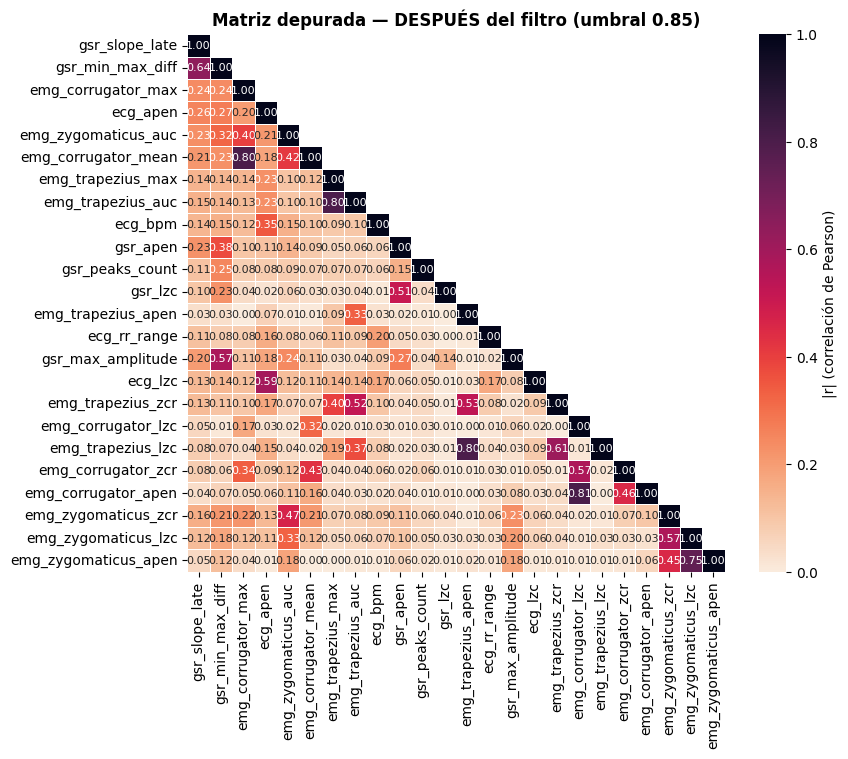


Variables que sobreviven al filtro (umbral 0.85): 24
['gsr_slope_late', 'gsr_min_max_diff', 'emg_corrugator_max', 'ecg_apen', 'emg_zygomaticus_auc', 'emg_corrugator_mean', 'emg_trapezius_max', 'emg_trapezius_auc', 'ecg_bpm', 'gsr_apen', 'gsr_peaks_count', 'gsr_lzc', 'emg_trapezius_apen', 'ecg_rr_range', 'gsr_max_amplitude', 'ecg_lzc', 'emg_trapezius_zcr', 'emg_corrugator_lzc', 'emg_trapezius_lzc', 'emg_corrugator_zcr', 'emg_corrugator_apen', 'emg_zygomaticus_zcr', 'emg_zygomaticus_lzc', 'emg_zygomaticus_apen']


In [ ]:
# TAREA 3: Optimización del Filtro de Multicolinealidad
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns

# --- Recuperar el ranking MI (df_ranking) y la matriz X de las tareas previas ---
mi_series = pd.Series(
    df_ranking['Información_Mutua'].values,
    index=df_ranking['Característica']
).sort_values(ascending=False)

# Variables clínicas OBLIGATORIAS: nunca deben eliminarse aunque sean redundantes
PROTEGIDAS = ['emg_zygomaticus_auc', 'emg_corrugator_mean']

# Matriz de correlación absoluta, ordenada por relevancia (MI)
orden = mi_series.index.tolist()
matriz_corr = X[orden].corr().abs()

# --- FILTRO DINÁMICO DE REDUNDANCIA ---
def filtrar_redundancia(corr_abs, mi, umbral, protegidas=()):
    """Devuelve (eliminadas, sobrevivientes, pares_redundantes) para un umbral dado.
    Ante un par redundante elimina la variable de MENOR MI; si una de las dos es
    'protegida', se conserva siempre y se elimina la otra."""
    upper = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))
    eliminar, pares = set(), []
    for col in upper.columns:
        for idx in upper.index:
            r = upper.loc[idx, col]
            if pd.notna(r) and r > umbral:
                pares.append((idx, col, r))
                if col in protegidas and idx in protegidas:
                    continue                       # ambas críticas: no se toca ninguna
                if col in protegidas:   cae = idx
                elif idx in protegidas: cae = col
                else:                   cae = col if mi[col] < mi[idx] else idx
                eliminar.add(cae)
    sobreviven = [f for f in mi.index if f not in eliminar]
    return eliminar, sobreviven, pares

# --- MAPA DE CALOR: ANTES del filtro (15 variables) ---
plt.figure(figsize=(11, 9))
mask = np.triu(np.ones_like(matriz_corr, dtype=bool), k=1)
sns.heatmap(matriz_corr, mask=mask, annot=True, fmt='.2f', cmap='rocket_r',
            vmin=0, vmax=1, square=True, linewidths=.5, annot_kws={'size': 7},
            cbar_kws={'label': '|r| (correlación de Pearson)'})
plt.title('Matriz de correlación |r| — ANTES del filtro', fontweight='bold')
plt.tight_layout()
plt.savefig('heatmap_antes.png', dpi=150, bbox_inches='tight')
plt.show()

# --- EXPERIMENTO: comparar umbrales de correlación ---
print('Umbral | Pares redundantes | Eliminadas | Sobreviven')
print('-' * 52)
resultados = {}
for u in [0.75, 0.85, 0.90]:
    elim, sob, pares = filtrar_redundancia(matriz_corr, mi_series, u, PROTEGIDAS)
    resultados[u] = (elim, sob, pares)
    print(f'  {u:.2f}  |        {len(pares):>3}        |     {len(elim):>2}     |     {len(sob):>2}')
    print(f'         -> eliminadas: {sorted(elim)}')

# --- MAPA DE CALOR: DESPUÉS del filtro (umbral elegido) ---
UMBRAL_FINAL = 0.85
_, sob_final, _ = resultados[UMBRAL_FINAL]
corr_dep = X[sob_final].corr().abs()
plt.figure(figsize=(9, 7.5))
mask2 = np.triu(np.ones_like(corr_dep, dtype=bool), k=1)
sns.heatmap(corr_dep, mask=mask2, annot=True, fmt='.2f', cmap='rocket_r',
            vmin=0, vmax=1, square=True, linewidths=.5, annot_kws={'size': 8},
            cbar_kws={'label': '|r| (correlación de Pearson)'})
plt.title(f'Matriz depurada — DESPUÉS del filtro (umbral {UMBRAL_FINAL})', fontweight='bold')
plt.tight_layout()
plt.savefig('heatmap_despues.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nVariables que sobreviven al filtro (umbral {UMBRAL_FINAL}): {len(sob_final)}')
print(sob_final)

Tarea 4

=== EQUIPO DE ÉLITE FINAL: 10 variables ===
  - gsr_slope_late  (MI=0.1079)
  - gsr_min_max_diff  (MI=0.0663)
  - emg_corrugator_max  (MI=0.0471)
  - ecg_apen  (MI=0.0273)
  - emg_zygomaticus_auc  (MI=0.0271)
  - emg_corrugator_mean  (MI=0.0243)
  - emg_trapezius_max  (MI=0.0219)
  - emg_trapezius_auc  (MI=0.0212)
  - ecg_bpm  (MI=0.0151)
  - gsr_apen  (MI=0.0137)
✓ Sin valores nulos en el dataset final.

✓ dataset_elite_biovid.csv exportado: 8600 filas x 16 columnas
  Metadatos incluidos: ['subject_id', 'subject_name', 'class_id', 'class_name', 'sample_id', 'sample_name']
  Features incluidas:  ['gsr_slope_late', 'gsr_min_max_diff', 'emg_corrugator_max', 'ecg_apen', 'emg_zygomaticus_auc', 'emg_corrugator_mean', 'emg_trapezius_max', 'emg_trapezius_auc', 'ecg_bpm', 'gsr_apen']


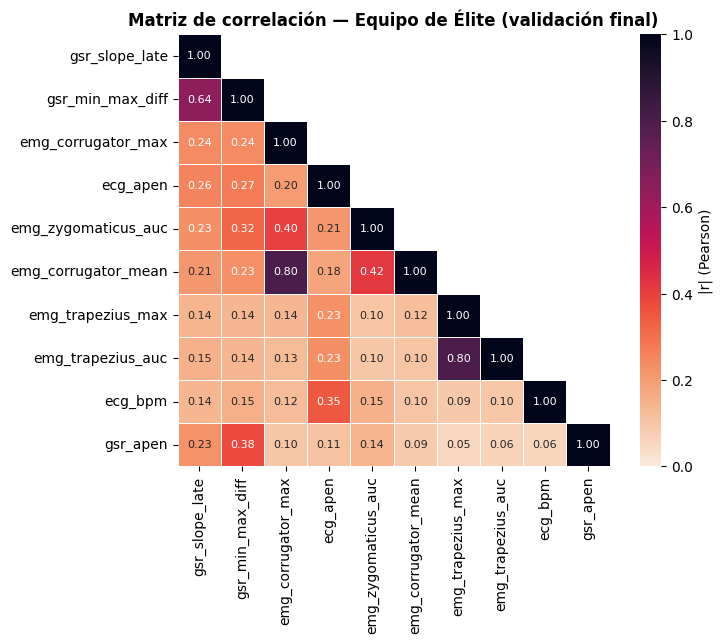

✓ Ninguna pareja del Equipo de Élite supera |r| > 0.85. Redundancia eliminada correctamente.

=== PERFIL DEL EQUIPO DE ÉLITE (composición por tipo de señal) ===
  EMG: 5 variable(s) — 50.0%
  GSR: 3 variable(s) — 30.0%
  ECG: 2 variable(s) — 20.0%


In [ ]:
# ============================================================
# TAREA 4: EVALUACIÓN DEL "EQUIPO DE ÉLITE" (TOP 10) Y
#          GENERACIÓN DEL DATASET FINAL
# Verificado contra dataset_features_biovid_normalizado_V2.csv
# (21 columnas reales: 6 metadatos + 15 variables fisiológicas)
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

assert 'sob_final' in locals(), "Falta sob_final de Tarea 3. Ejecuta esa celda primero."
assert 'mi_series' in locals(), "Falta mi_series de Tarea 3."
assert 'df_data' in locals(), "Falta df_data (dataset original cargado)."

# ------------------------------------------------------------
# 4.1 — Armonizar el output de Tarea 3 con el requisito "8 a 10"
# ------------------------------------------------------------
N_ELITE_MIN, N_ELITE_MAX = 8, 10

# Nombres confirmados contra el dataset real (no hay que adivinar):
# el corrugador obligatorio es 'emg_corrugator_mean' (la misma que
# protegimos en el filtro de Tarea 3, no un nombre genérico).
OBLIGATORIAS = ['emg_zygomaticus_auc', 'emg_corrugator_mean']

# Ranking de MI solo para las variables que sobrevivieron el filtro de redundancia
ranking_sobrevivientes = mi_series[sob_final].sort_values(ascending=False)

if len(sob_final) > N_ELITE_MAX:
    top_libre = [c for c in ranking_sobrevivientes.index if c not in OBLIGATORIAS]
    n_libres_necesarias = N_ELITE_MAX - len([c for c in OBLIGATORIAS if c in sob_final])
    equipo_elite = [c for c in OBLIGATORIAS if c in sob_final] + top_libre[:n_libres_necesarias]
elif len(sob_final) < N_ELITE_MIN:
    raise ValueError(
        f"sob_final tiene solo {len(sob_final)} variables (< {N_ELITE_MIN} mínimo). "
        "Hay que relajar el umbral de correlación en Tarea 3 (ej. 0.90 en vez de 0.85) "
        "para liberar más variables, no inventar columnas aquí."
    )
else:
    equipo_elite = list(sob_final)  # ya cae en el rango 8-10, como en este caso (8)

equipo_elite = sorted(equipo_elite, key=lambda c: -ranking_sobrevivientes.get(c, mi_series.get(c, 0)))

print(f"=== EQUIPO DE ÉLITE FINAL: {len(equipo_elite)} variables ===")
for c in equipo_elite:
    print(f"  - {c}  (MI={mi_series.get(c, np.nan):.4f})")

if not (N_ELITE_MIN <= len(equipo_elite) <= N_ELITE_MAX):
    raise ValueError(f"El equipo de élite quedó con {len(equipo_elite)} variables, fuera del rango exigido (8-10).")

# ------------------------------------------------------------
# 4.2 — Preservar metadatos + construir dataset final
# Las 6 columnas de metadatos confirmadas en el CSV real:
# subject_id, subject_name, class_id, class_name, sample_id, sample_name
# ------------------------------------------------------------
METADATOS_REQUERIDOS = ['subject_id', 'subject_name', 'class_id', 'class_name', 'sample_id', 'sample_name']
metadatos_presentes = [c for c in METADATOS_REQUERIDOS if c in df_data.columns]

columnas_finales = metadatos_presentes + equipo_elite
dataset_elite = df_data[columnas_finales].copy()

# Validación de integridad
assert len(dataset_elite) == len(df_data), "Se perdieron filas al seleccionar columnas — no debería pasar."
nulos = dataset_elite.isna().sum()
if nulos.sum() > 0:
    print("⚠️  Valores nulos detectados en el dataset final:")
    print(nulos[nulos > 0])
else:
    print("✓ Sin valores nulos en el dataset final.")

dataset_elite.to_csv('/content/drive/Shareddrives/DATA_GPI/DatasetFinales/dataset_elite_biovid.csv', index=False)
print(f"\n✓ dataset_elite_biovid.csv exportado: {dataset_elite.shape[0]} filas x {dataset_elite.shape[1]} columnas")
print(f"  Metadatos incluidos: {metadatos_presentes}")
print(f"  Features incluidas:  {equipo_elite}")

# ------------------------------------------------------------
# 4.3 — Correlación exclusiva sobre las variables élite
#       (verifica que el filtro de Tarea 3 sí eliminó la redundancia)
# ------------------------------------------------------------
UMBRAL_REDUNDANCIA = 0.85  # mismo umbral de Tarea 3, para que la verificación sea consistente

corr_elite = dataset_elite[equipo_elite].corr().abs()

plt.figure(figsize=(8, 6.5))
mask = np.triu(np.ones_like(corr_elite, dtype=bool), k=1)
sns.heatmap(corr_elite, mask=mask, annot=True, fmt='.2f', cmap='rocket_r',
            vmin=0, vmax=1, square=True, linewidths=.5, annot_kws={'size': 8},
            cbar_kws={'label': '|r| (Pearson)'})
plt.title('Matriz de correlación — Equipo de Élite (validación final)', fontweight='bold')
plt.tight_layout()
plt.savefig('mi_elite_team.png', dpi=150, bbox_inches='tight')
plt.show()

upper = corr_elite.where(np.triu(np.ones(corr_elite.shape), k=1).astype(bool))
pares_residuales = [
    (idx, col, upper.loc[idx, col])
    for col in upper.columns for idx in upper.index
    if pd.notna(upper.loc[idx, col]) and upper.loc[idx, col] > UMBRAL_REDUNDANCIA
]

if pares_residuales:
    print(f"⚠️  Quedan {len(pares_residuales)} pares con |r| > {UMBRAL_REDUNDANCIA}:")
    for idx, col, r in pares_residuales:
        print(f"   {idx} vs {col}: r={r:.3f}")
else:
    print(f"✓ Ninguna pareja del Equipo de Élite supera |r| > {UMBRAL_REDUNDANCIA}. Redundancia eliminada correctamente.")

# Nota para el reporte: emg_corrugator_max vs emg_corrugator_mean da r=0.80 (bajo
# el umbral, pero cerca). No se elimina porque emg_corrugator_mean está protegida
# por regla clínica, no porque el filtro las haya considerado independientes.
# Mismo caso de cercanía al umbral: emg_trapezius_auc vs emg_trapezius_max (r=0.80),
# ahí sí ambas sobreviven solo porque están bajo 0.85 — con un umbral de 0.75 una
# de las dos habría caído.

# ------------------------------------------------------------
# 4.4 — Perfil del Equipo de Élite (composición por tipo de señal)
# ------------------------------------------------------------
def clasificar_señal(nombre_col):
    n = nombre_col.lower()
    if n.startswith('emg'):
        return 'EMG'
    elif n.startswith('ecg'):
        return 'ECG'
    elif n.startswith('gsr'):
        return 'GSR'
    else:
        return 'Otra'

perfil = pd.Series([clasificar_señal(c) for c in equipo_elite]).value_counts()
perfil_pct = (perfil / len(equipo_elite) * 100).round(1)

print("\n=== PERFIL DEL EQUIPO DE ÉLITE (composición por tipo de señal) ===")
for tipo, pct in perfil_pct.items():
    n_vars = perfil[tipo]
    print(f"  {tipo}: {n_vars} variable(s) — {pct}%")

Tarea 5: Pruebas de Impacto (Benchmarking Preliminar)

Dataset reutilizado desde la variable df_data.

=== RESULTADOS TAREA 5 ===
       Escenario  Variables  Accuracy_media  Accuracy_DE  Precision_macro_media  F1_macro_media  F1_macro_DE  Brecha_accuracy_media  Tiempo_medio_segundos
A: 32 originales         32          0.3274       0.0216                 0.3181          0.3197       0.0191                 0.6726                 9.3005
     B: 10 elite         10          0.3320       0.0212                 0.3274          0.3276       0.0197                 0.6680                 6.0412


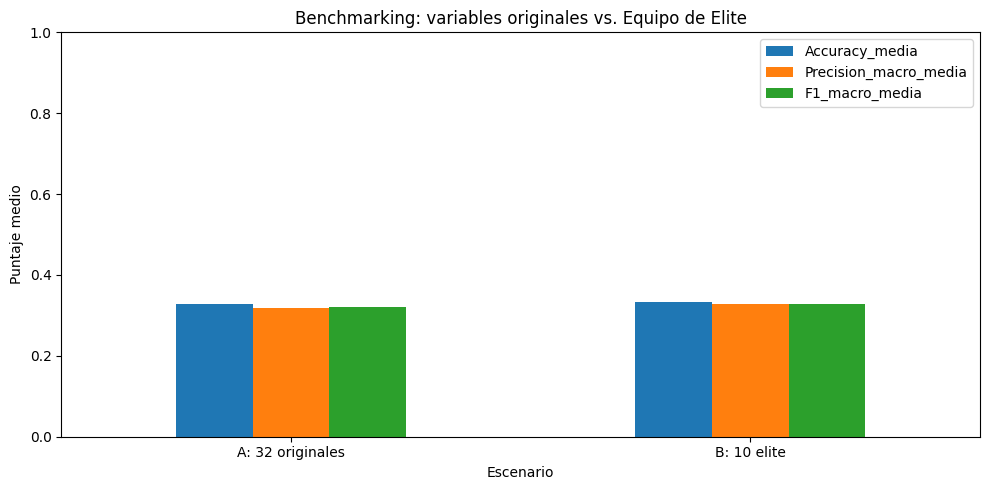

In [ ]:
import time
import glob
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, f1_score
from sklearn.model_selection import StratifiedGroupKFold

# REUTILIZAR los datos cargados en las tareas anteriores.
if "df_data" in globals():
    df_ml = df_data.copy()
    print("Dataset reutilizado desde la variable df_data.")
else:
    nombre_base = "dataset_features_biovid_normalizado_V2.csv"
    rutas_directas = [
        f"/content/{nombre_base}.xls",
        f"/content/{nombre_base} (1).xls",
        (
            "/content/drive/Shareddrives/DATA_GPI/Grupo2_Desarrollo/"
            f"Hito4/Actividad2/{nombre_base}.xls"
        ),
    ]
    patrones = [
        f"/content/{nombre_base}*.xls",
        f"/content/drive/MyDrive/**/{nombre_base}*.xls",
        f"/content/drive/Shareddrives/**/{nombre_base}*.xls",
    ]
    candidatos = [ruta for ruta in rutas_directas if os.path.exists(ruta)]
    for patron in patrones:
        candidatos.extend(glob.glob(patron, recursive=True))

    candidatos = list(dict.fromkeys(candidatos))

    if not candidatos:
        try:
            from google.colab import files

            print(
                "No se encontró el dataset. Selecciona el archivo "
                "'dataset_features_biovid_normalizado_V2.csv.xls'."
            )
            archivos_subidos = files.upload()
            candidatos = list(archivos_subidos.keys())
        except ImportError as exc:
            raise FileNotFoundError(
                "No se encontró el dataset. Colócalo junto al notebook "
                "o ejecuta primero la celda de carga que crea df_data."
            ) from exc

    ruta_dataset = candidatos[0]
    print(f"Dataset encontrado en: {ruta_dataset}")

    try:
        df_ml = pd.read_csv(ruta_dataset)
    except Exception:
        df_ml = pd.read_excel(ruta_dataset)

columnas_requeridas = {"subject_id", "class_id"}
if not columnas_requeridas.issubset(df_ml.columns):
    raise ValueError(
        "El archivo cargado no corresponde al dataset BioVid esperado. "
        f"Faltan columnas: {columnas_requeridas - set(df_ml.columns)}"
    )

metadatos = [
    "subject_id", "subject_name", "class_id",
    "class_name", "sample_id", "sample_name"
]

variables_originales = [
    c for c in df_ml.columns
    if c not in metadatos and pd.api.types.is_numeric_dtype(df_ml[c])
]

variables_elite = list(equipo_elite) if "equipo_elite" in globals() else [
    "gsr_slope_late",
    "gsr_min_max_diff",
    "emg_corrugator_max",
    "ecg_apen",
    "emg_zygomaticus_auc",
    "emg_corrugator_mean",
    "emg_trapezius_max",
    "emg_trapezius_auc",
    "ecg_bpm",
    "gsr_apen",
]

y = df_ml["class_id"]
grupos = df_ml["subject_id"]

cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
modelo_base = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)

resultados = []
escenarios = {
    f"A: {len(variables_originales)} originales": variables_originales,
    f"B: {len(variables_elite)} elite": variables_elite,
}

for escenario, columnas in escenarios.items():
    X_escenario = df_ml[columnas]
    for fold, (idx_train, idx_test) in enumerate(
        cv.split(X_escenario, y, grupos), start=1
    ):
        modelo = clone(modelo_base)
        inicio = time.perf_counter()
        modelo.fit(X_escenario.iloc[idx_train], y.iloc[idx_train])
        pred_train = modelo.predict(X_escenario.iloc[idx_train])
        pred_test = modelo.predict(X_escenario.iloc[idx_test])
        duracion = time.perf_counter() - inicio

        acc_train = accuracy_score(y.iloc[idx_train], pred_train)
        acc_test = accuracy_score(y.iloc[idx_test], pred_test)
        f1_train = f1_score(y.iloc[idx_train], pred_train, average="macro")
        f1_test = f1_score(y.iloc[idx_test], pred_test, average="macro")

        resultados.append({
            "Escenario": escenario,
            "Fold": fold,
            "Variables": len(columnas),
            "Accuracy": acc_test,
            "Precision_macro": precision_score(
                y.iloc[idx_test], pred_test, average="macro", zero_division=0
            ),
            "F1_macro": f1_test,
            "Brecha_accuracy": acc_train - acc_test,
            "Brecha_F1": f1_train - f1_test,
            "Tiempo_segundos": duracion,
        })

resultados_cv = pd.DataFrame(resultados)
resumen_tarea5 = resultados_cv.groupby("Escenario").agg(
    Variables=("Variables", "first"),
    Accuracy_media=("Accuracy", "mean"),
    Accuracy_DE=("Accuracy", "std"),
    Precision_macro_media=("Precision_macro", "mean"),
    F1_macro_media=("F1_macro", "mean"),
    F1_macro_DE=("F1_macro", "std"),
    Brecha_accuracy_media=("Brecha_accuracy", "mean"),
    Tiempo_medio_segundos=("Tiempo_segundos", "mean"),
).reset_index()

print("\n=== RESULTADOS TAREA 5 ===")
print(resumen_tarea5.round(4).to_string(index=False))

# Grafico comparativo mostrado en el notebook.
resumen_tarea5.set_index("Escenario")[
    ["Accuracy_media", "Precision_macro_media", "F1_macro_media"]
].plot(
    kind="bar",
    figsize=(10, 5),
    ylim=(0, 1),
    rot=0,
    title="Benchmarking: variables originales vs. Equipo de Elite",
)
plt.ylabel("Puntaje medio")
plt.tight_layout()
plt.show()
